In [1]:
import numpy as np
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score, auc
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from lightgbm.callback import early_stopping

In [2]:
TRAIN_LOCS_KEY = 'train_locs'
TRAIN_IDS_KEY = 'train_ids'
TAXON_IDS_KEY = 'taxon_ids'
TAXON_NAME_KEY = 'taxon_names'

TEST_LOCS_KEY = 'test_locs'
TEST_IDS_KEY = 'test_pos_inds'

Reading the file:

In [3]:
filepath = os.path.join(os.getcwd(), '/Users/Maya/Desktop/species/species_train.npz')
data = np.load(filepath, allow_pickle=True)
train_locs = data[TRAIN_LOCS_KEY]
train_ids = data[TRAIN_IDS_KEY]
taxon_ids = data[TAXON_IDS_KEY]
taxon_names = data[TAXON_NAME_KEY]

Reading the test file:

In [4]:
test_filepath = os.path.join(os.getcwd(), '/Users/Maya/Desktop/species/species_test.npz')
test_data = np.load(test_filepath, allow_pickle=True)
test_locs = test_data[TEST_LOCS_KEY]
test_ids = test_data[TEST_IDS_KEY]

Mapping the taxon ids to taxon latin names: 

In [5]:
species_ids_names = dict(zip(data['taxon_ids'], data['taxon_names']))  # latin names of species 

Create pandas Dataframe from the train data: 

In [6]:
df = pd.DataFrame({
    'latitude': train_locs[:, 0],
    'longitude': train_locs[:, 1], 
    'taxon_id': data[TRAIN_IDS_KEY]
})
df['taxon_name'] = [species_ids_names[id] for id in data[TRAIN_IDS_KEY].astype(int)]
df.head()

,latitude,longitude,taxon_id,taxon_name
0,-18.286728,143.481247,31529,Lophognathus gilberti
1,-13.099798,130.783646,31529,Lophognathus gilberti
2,-13.965274,131.695145,31529,Lophognathus gilberti
3,-12.853950,132.800507,31529,Lophognathus gilberti
4,-12.196790,134.279327,31529,Lophognathus gilberti


Create pandas Dataframe from the test data: 

In [7]:
rows = [
    [test_locs[loc_id][0], test_locs[loc_id][1], taxon_id]
    for taxon_id, loc_ids in zip(taxon_ids, test_ids)
    for loc_id in loc_ids
]

In [8]:
test_df = pd.DataFrame(rows, columns=["latitude", "longitude", "taxon_id"])
test_df['taxon_name'] = [species_ids_names[id] for id in test_df["taxon_id"].astype(int)]
test_df.head()

,latitude,longitude,taxon_id,taxon_name
0,-19.884237,126.052979,31529,Lophognathus gilberti
1,-20.219316,124.723953,31529,Lophognathus gilberti
2,-20.053690,125.386505,31529,Lophognathus gilberti
3,-19.973000,126.462440,31529,Lophognathus gilberti
4,-19.962839,124.980362,31529,Lophognathus gilberti


In [9]:
test_df.shape

(1706646, 4)

Data Cleanining: 

<small>1. Check for missing or invalid coordinates:</small>

In [10]:
df = df.dropna(subset=['latitude', 'longitude'])
test_df = test_df.dropna(subset=['latitude', 'longitude'])
df = df[(df['latitude'].between(-90, 90)) & (df['longitude'].between(-180, 180))]
test_df = test_df[(test_df['latitude'].between(-90, 90)) & (test_df['longitude'].between(-180, 180))]
df.shape, test_df.shape

((272037, 4), (1706646, 4))

<small>2. Remove any duplicates or nearly duplicates (observations that are extremely close):</small>

In [11]:
df['lat_rounded'] = df['latitude'].round(5)
df['lon_rounded'] = df['longitude'].round(5)
test_df['lat_rounded'] = test_df['latitude'].round(5)
test_df['lon_rounded'] = test_df['longitude'].round(5)

In [12]:
df = df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', 'taxon_id'])
test_df = test_df.drop_duplicates(subset=['lat_rounded', 'lon_rounded', 'taxon_id'])
df.shape, test_df.shape

((251822, 6), (1706646, 6))

<small>4. Validate species IDs: </small>

In [13]:
df['taxon_id'].isna().sum(), test_df['taxon_id'].isna().sum()

(np.int64(0), np.int64(0))

<small>5. Only keep birds:</small>

<small>Note: Only run the next 2 blocks one time as they take a few seconds:</small>

In [14]:
taxa = pd.read_csv('/Users/Maya/Desktop/species/taxa.csv')
birds = taxa[taxa['class'] == 'Aves']
bird_taxon_ids = set(birds['id'])
len(bird_taxon_ids)

32140

In [15]:
df = df[df['taxon_id'].isin(bird_taxon_ids)].copy()
test_df = test_df[test_df['taxon_id'].isin(bird_taxon_ids)].copy()
df.shape, test_df.shape

((162642, 6), (1323320, 6))

<small>6. Convert to categorical labels:</small>

In [16]:
le = LabelEncoder()
le.fit(pd.concat([df['taxon_id'], test_df['taxon_id']]))
df['label'] = le.transform(df['taxon_id'])
test_df['label'] = le.transform(test_df['taxon_id'])

<small>7. Append the climate data</small>

In [17]:
import rasterio
import numpy as np
import os

base_dir = os.getcwd()  # assumes folders are in the same directory as this notebook

def load_stack(folder_name):
    folder = os.path.join(base_dir, folder_name)
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".tif")])
    if len(files) != 12:
        raise RuntimeError(f"Expected 12 GeoTIFFs in {folder_name}, found {len(files)}.")
    layers = []
    transform = None
    for f in files:
        with rasterio.open(f) as src:
            layers.append(src.read(1))
            transform = src.transform  # all months share the same transform
    return np.stack(layers), transform  # shape: (12, H, W), and affine transform

tmin, transform = load_stack("wc2.1_2.5m_tmin")
tmax, _         = load_stack("wc2.1_2.5m_tmax")
prec, _         = load_stack("wc2.1_2.5m_prec")

print("Stacks loaded. Shapes:",
      "tmin", tmin.shape, "tmax", tmax.shape, "prec", prec.shape)
print("Transform:", transform)

Stacks loaded. Shapes: tmin (12, 4320, 8640) tmax (12, 4320, 8640) prec (12, 4320, 8640)
Transform: | 0.04, 0.00,-180.00|
| 0.00,-0.04, 90.00|
| 0.00, 0.00, 1.00|


In [18]:
#Cleaning the data again as the precipitation values are very large, so I'll normalize them
from rasterio.transform import rowcol
import numpy as np

def get_climate_for_points(df, transform, tmin, tmax, prec, lat_col="latitude", lon_col="longitude"):
    # Convert lat/lon → raster indices
    rows, cols = rowcol(transform, df[lon_col].values, df[lat_col].values)
    rows = np.clip(rows, 0, tmin.shape[1]-1)
    cols = np.clip(cols, 0, tmin.shape[2]-1)

    # Helper: clean up weird values (NoData etc.)
    def clean(arr):
        arr = arr.astype(float)
        arr[arr > 1e4] = np.nan  # remove unrealistic large values
        return arr

    tmin = clean(tmin)
    tmax = clean(tmax)
    prec = clean(prec)

    # Extract values and average across 12 months safely
    tmin_mean = np.nanmean(tmin[:, rows, cols], axis=0)
    tmax_mean = np.nanmean(tmax[:, rows, cols], axis=0)
    prec_mean = np.nanmean(prec[:, rows, cols], axis=0)

    return tmin_mean, tmax_mean, prec_mean

In [19]:
tmin_avg, tmax_avg, prec_avg = get_climate_for_points(df, transform, tmin, tmax, prec)

In [20]:
test_tmin_avg, test_tmax_avg, test_prec_avg = get_climate_for_points(test_df, transform, tmin, tmax, prec)

In [21]:
df["Tmin_avg"] = tmin_avg
df["Tmax_avg"] = tmax_avg
df["Prec_avg"] = prec_avg

df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
53,21.086105,-86.852867,20.967000,31.436000,103.416667
54,19.186003,-96.199600,19.327333,31.831333,117.833333
55,17.538877,-89.113724,19.496333,30.576333,125.583333
56,20.648556,-105.220955,19.674123,31.835527,87.750000
57,18.409698,-95.096657,20.515000,29.086000,156.750000


In [22]:
test_df["Tmin_avg"] = test_tmin_avg
test_df["Tmax_avg"] = test_tmax_avg
test_df["Prec_avg"] = test_prec_avg

test_df[["latitude","longitude","Tmin_avg","Tmax_avg","Prec_avg"]].head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg
784,19.289352,-89.842888,1.885033e+01,3.272100e+01,91.750000
785,20.777590,-88.534241,1.882467e+01,3.272433e+01,103.833333
786,21.513868,-86.804565,2.165833e+01,3.071667e+01,100.250000
787,18.710384,-94.898964,-3.400000e+38,-3.400000e+38,-32768.000000
788,21.509193,-88.522995,1.973447e+01,3.149773e+01,73.250000


In [23]:
out_path = "bird_species_rerun_with_averaged_climate.csv"
df.to_csv(out_path, index=False)
out_path, df.shape

('bird_species_rerun_with_averaged_climate.csv', (162642, 10))

In [24]:
out_path = "test_bird_species_rerun_with_averaged_climate.csv"
test_df.to_csv(out_path, index=False)
out_path, test_df.shape

('test_bird_species_rerun_with_averaged_climate.csv', (1323320, 10))

In [25]:
df = pd.read_csv('bird_species_rerun_with_averaged_climate.csv')

In [26]:
test_df = pd.read_csv('test_bird_species_rerun_with_averaged_climate.csv')

<small>8. Clean the climate data</small>

In [27]:
df['Tmin_avg'] = df['Tmin_avg'].mask(df['Tmin_avg'] < -1e+30, np.nan)
df['Tmax_avg'] = df['Tmax_avg'].mask(df['Tmax_avg'] < -1e+30, np.nan)
df['Prec_avg'] = df['Prec_avg'].mask(df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {df.shape}")
df = df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {df.shape}")

Shape with nan data: (162642, 10)
Shape without nan data: (161432, 10)


In [28]:
len(test_df)

1323320

In [29]:
test_df['Tmin_avg'] = test_df['Tmin_avg'].mask(test_df['Tmin_avg'] < -1e+30, np.nan)
test_df['Tmax_avg'] = test_df['Tmax_avg'].mask(test_df['Tmax_avg'] < -1e+30, np.nan)
test_df['Prec_avg'] = test_df['Prec_avg'].mask(test_df['Prec_avg'] < 0, np.nan)
print(f"Shape with nan data: {test_df.shape}")
test_df = test_df.dropna(subset=['Tmin_avg', 'Tmax_avg', 'Prec_avg'])
print(f"Shape without nan data: {test_df.shape}")

Shape with nan data: (1323320, 10)
Shape without nan data: (928354, 10)


<small>Note: mention in the report that we lost a lot of data because of removing NaN temperature, in the ociens mainly.</small>

In [30]:
(df['Tmax_avg'] < df['Tmin_avg']).sum(), (test_df['Tmax_avg'] < test_df['Tmin_avg']).sum()

(np.int64(0), np.int64(0))

<small>Add sin feature to capture circularity</small>

In [31]:
df['lat_sin'] = np.sin(np.deg2rad(df['latitude']))
df['lat_cos'] = np.cos(np.deg2rad(df['latitude']))
df['lon_sin'] = np.sin(np.deg2rad(df['longitude']))
df['lon_cos'] = np.cos(np.deg2rad(df['longitude']))

In [32]:
test_df['lat_sin'] = np.sin(np.deg2rad(test_df['latitude']))
test_df['lat_cos'] = np.cos(np.deg2rad(test_df['latitude']))
test_df['lon_sin'] = np.sin(np.deg2rad(test_df['longitude']))
test_df['lon_cos'] = np.cos(np.deg2rad(test_df['longitude']))

In [33]:
df.shape, test_df.shape

((161432, 14), (928354, 14))

<small>9. Split the data to x and y and normalize the climate features</small>

In [34]:
X_data = df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_data = df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
scaler = StandardScaler()
scaler.fit(X_data[climate_features])
X_scaled = X_data.copy()
X_scaled[climate_features] = scaler.transform(X_data[climate_features])
X_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos
count,161432.000000,161432.000000,1.614320e+05,1.614320e+05,1.614320e+05,161432.000000,161432.000000,161432.000000,161432.000000
mean,14.827329,-8.036515,-6.197310e-17,2.929638e-16,3.098655e-17,0.230808,0.820155,-0.203034,0.042523
std,31.900029,95.705462,1.000003e+00,1.000003e+00,1.000003e+00,0.509097,0.122050,0.770315,0.602984
min,-75.284950,-178.060320,-6.699036e+00,-6.690300e+00,-1.635481e+00,-0.967201,0.254012,-1.000000,-0.999791
25%,-21.050622,-96.105056,-6.488781e-01,-7.633616e-01,-6.553056e-01,-0.359193,0.747490,-0.968077,-0.459039
50%,26.165924,-43.440056,1.560563e-02,1.265317e-01,-1.806941e-01,0.440972,0.831109,-0.673665,0.067571
75%,40.959681,75.385002,6.814487e-01,7.350146e-01,3.936545e-01,0.655528,0.914683,0.524633,0.545473
max,72.515430,178.827590,2.250907e+00,2.213666e+00,1.319785e+01,0.953798,1.000000,1.000000,1.000000


In [35]:
X_test = test_df.drop(columns=['taxon_id', 'taxon_name', 'lat_rounded', 'lon_rounded', 'label'])
y_test = test_df['label']
climate_features = ['Tmin_avg', 'Tmax_avg', 'Prec_avg']
non_scaled_features = ['latitude', 'longitude']
# scale climate 
X_test_scaled = X_test.copy()
X_test_scaled[climate_features] = scaler.transform(X_test[climate_features])
X_test_scaled.describe()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos
count,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000,928354.000000
mean,13.171677,13.497898,0.183610,0.289493,-0.008040,0.198286,0.853137,0.094081,0.314364
std,29.127638,77.380268,1.432959,1.412140,1.242831,0.455790,0.158418,0.745243,0.580464
min,-85.600830,-179.933670,-6.928313,-7.189774,-1.635481,-0.997054,0.076705,-1.000000,-1.000000
25%,-12.422070,-59.177242,-0.792492,-0.690674,-0.923564,-0.215112,0.773541,-0.837545,-0.177202
50%,11.103984,23.309443,0.622043,0.861617,-0.350935,0.192590,0.913240,0.389406,0.445380
75%,38.710465,74.511734,1.357427,1.342591,0.594849,0.625385,0.979165,0.720192,0.853618
max,82.845260,179.994780,2.595104,2.364347,12.102457,0.992213,1.000000,1.000000,1.000000


<small>9. Split to train and validation sets</small>

In [36]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_data,
                                                  test_size=0.2,
                                                  random_state=42, 
                                                  stratify=y_data)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

Exploratory Data Analysis:

In [37]:
# Hajer

Models:

<small>Model 1: LightGBM<br> This model depends on decision tree and has hyperparameters</small>


In [38]:
# Model 1 (a): LightGBM with probability distribution output
# Note to Maya: This is not very important model, Model 1 (b) is more important
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test_scaled, label=y_test)
boosting_types = ['gbdt']
num_leaves = [31]
max_depths = [-1]
for boosting_type in boosting_types: 
    for num_leaf in num_leaves: 
        for max_depth in max_depths: 
            params = {
                'objective': 'multiclass',
                'num_class': 285,
                'learning_rate': 0.05,
                'metric': 'multi_logloss',
                'boosting_type': "gbdt",
                'max_depth': 30, 
                'num_leaves': 31, 
                'lambda_l1': 0.5,
                'lambda_l2': 1.0, 
                'is_unbalance': True
            }
            clf = lgb.train(
                params,
                train_data,
                valid_sets=[test_data],
                num_boost_round=2000,
                callbacks= [early_stopping(stopping_rounds=100)]
            )
            y_pred_prob = clf.predict(X_test_scaled, num_iteration=clf.best_iteration)
            y_pred = y_pred_prob.argmax(axis=1)
            print("Accuracy:", accuracy_score(y_test, y_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000856 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 129145, number of used features: 9
[LightGBM] [Info] Start training from score -6.537582
[LightGBM] [Info] Start training from score -6.123244
[LightGBM] [Info] Start training from score -4.959652
[LightGBM] [Info] Start training from score -7.798399
[LightGBM] [Info] Start training from score -8.079812
[LightGBM] [Info] Start training from score -7.641557
[LightGBM] [Info] Start training from score -4.455471
[LightGBM] [Info] Start training from score -5.718958
[LightGBM] [Info] Start training from score -7.817447
[LightGBM] [Info] Start training from score -8.031021
[LightGBM] [Info] Start training from score -6.223514
[LightGBM] [Info] Start training from score -6.162889

In [39]:
# Note to Maya: If this doesn't work just comment it
print(f1_score(y_test, y_pred, average='macro'))
print("Top-5 acc", top_k_accuracy_score(y_test, y_pred_prob, k=5, labels=list(set(y_train))))
print("Top-7 acc", top_k_accuracy_score(y_test, y_pred_prob, k=7, labels=list(set(y_train))))
print("Top-10 acc", top_k_accuracy_score(y_test, y_pred_prob, k=10, labels=list(set(y_train))))

0.05731142607125948
Top-5 acc 0.3127126074751657
Top-7 acc 0.4165221456470269
Top-10 acc 0.5504441193768757


In [40]:
# Model 1 (b): LightGBM with vector binary output

In [41]:
train_df = X_train.copy()
train_df['label'] = y_train
grouped_train = (
    train_df.groupby(list(X_train.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)

In [42]:
train_df = X_val.copy()
train_df['label'] = y_val
grouped_val = (
    train_df.groupby(list(X_val.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)

In [43]:
grouped_train.head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos,labels
0,-75.284950,-102.746760,-3.808437,-4.360072,-0.285590,-0.967201,0.254012,-0.975355,-0.220642,[202]
1,-75.250980,-0.071389,-6.699036,-6.690300,-1.494474,-0.967050,0.254585,-0.001246,0.999999,[202]
2,-67.566444,-68.129295,-2.445172,-3.109188,-0.971713,-0.924323,0.381612,-0.928027,0.372513,[202]
3,-65.889150,-66.195350,-2.298080,-3.007162,-0.418000,-0.912757,0.408503,-0.914927,0.403620,[202]
4,-65.063310,-64.039406,-2.333057,-3.051751,-0.096433,-0.906774,0.421617,-0.899095,0.437753,[202]


In [44]:
grouped_train.shape

(122166, 10)

In [45]:
grouped_val.head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos,labels
0,-65.075900,-63.996357,-2.241169,-2.978719,-0.092994,-0.906867,0.421417,-0.898766,0.438428,[202]
1,-64.876114,-62.542420,-2.561603,-3.333969,-0.428318,-0.905392,0.424577,-0.887352,0.461092,[202]
2,-64.823880,-62.856915,-2.273834,-3.036636,-0.170376,-0.905004,0.425402,-0.889870,0.456214,[202]
3,-64.696686,-62.739140,-2.480519,-3.265628,-0.301067,-0.904058,0.427410,-0.888930,0.458042,[27]
4,-64.689300,-61.967083,-2.590112,-3.407331,-0.591680,-0.904003,0.427527,-0.882678,0.469979,[202]


In [46]:
grouped_val.shape

(31667, 10)

In [47]:
test_df = X_test_scaled.copy()
test_df['label'] = y_test
grouped_test = (
    test_df.groupby(list(X_test.columns))['label']
    .apply(list)
    .reset_index(name='labels')
)
grouped_test.shape

(75432, 10)

In [48]:
grouped_test[290: 300]

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos,labels
290,-69.531660,33.893047,-4.649422,-4.999933,-1.112721,-0.936866,0.349690,0.557644,0.830080,"[27, 28]"
291,-69.509710,-67.743520,-3.580448,-3.979311,-1.286401,-0.936732,0.350049,-0.925498,0.378753,"[27, 28]"
292,-69.483080,-69.881020,-3.970080,-4.315951,-1.135076,-0.936569,0.350484,-0.938980,0.343971,"[27, 28]"
293,-69.260826,68.967660,-3.847977,-4.427454,-1.135076,-0.935202,0.354114,0.933378,0.358895,"[202, 27, 28]"
294,-69.244560,-70.887570,-4.460877,-4.716619,-1.083488,-0.935102,0.354380,-0.944878,0.327423,[27]
295,-69.243250,-62.398620,-3.433829,-4.037443,-1.315635,-0.935093,0.354401,-0.886192,0.463317,"[202, 27, 28]"
296,-69.226600,158.234100,-3.536519,-4.371476,-1.252009,-0.934990,0.354673,0.370815,-0.928707,"[202, 27, 28]"
297,-69.208015,77.470505,-4.085506,-4.695692,-1.264046,-0.934875,0.354976,0.976184,0.216942,"[202, 27, 28]"
298,-69.194860,33.190598,-4.364435,-4.757293,-1.019862,-0.934794,0.355191,0.547426,0.836854,"[27, 28]"
299,-69.048870,-63.485900,-3.532068,-4.056594,-1.286401,-0.933886,0.357572,-0.894825,0.446418,"[202, 27, 28]"


In [49]:
mlb = MultiLabelBinarizer(classes=range(285))
Y_train = mlb.fit_transform(grouped_train['labels'])
Y_test = mlb.transform(grouped_test['labels'])
X_train_ready = grouped_train.drop(columns=['labels'])
X_test_ready = grouped_test.drop(columns=['labels'])


In [50]:
Y_val = mlb.transform(grouped_val['labels'])
X_val_ready = grouped_val.drop(columns=['labels'])

In [51]:
X_train_ready_no_cos = X_train_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])
X_test_ready_no_cos = X_test_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])

X_train_ready.head()

,latitude,longitude,Tmin_avg,Tmax_avg,Prec_avg,lat_sin,lat_cos,lon_sin,lon_cos
0,-75.284950,-102.746760,-3.808437,-4.360072,-0.285590,-0.967201,0.254012,-0.975355,-0.220642
1,-75.250980,-0.071389,-6.699036,-6.690300,-1.494474,-0.967050,0.254585,-0.001246,0.999999
2,-67.566444,-68.129295,-2.445172,-3.109188,-0.971713,-0.924323,0.381612,-0.928027,0.372513
3,-65.889150,-66.195350,-2.298080,-3.007162,-0.418000,-0.912757,0.408503,-0.914927,0.403620
4,-65.063310,-64.039406,-2.333057,-3.051751,-0.096433,-0.906774,0.421617,-0.899095,0.437753


In [52]:
X_val_ready_no_cos = X_val_ready.drop(columns=['lat_sin', 'lat_cos', 'lon_sin', 'lon_cos'])

In [53]:
from sklearn.multioutput import MultiOutputClassifier

base_model = lgb.LGBMClassifier(
    objective='binary',     # because each label is a binary classification
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1
)
multi_model = MultiOutputClassifier(base_model)
# Y_pred_proba = np.column_stack([p[:, 1] for p in Y_pred_proba])  # take probability of class 1 for each label
# Y_pred = (Y_pred_proba > 0.5).astype(int)


In [54]:
multi_model.fit(X_train_ready, Y_train)
Y_pred_proba = multi_model.predict_proba(X_val_ready)

[LightGBM] [Info] Number of positive: 187, number of negative: 121979
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 122166, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001531 -> initscore=-6.480496
[LightGBM] [Info] Start training from score -6.480496
[LightGBM] [Info] Number of positive: 283, number of negative: 121883
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001799 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 122166, number of used features: 9
[LightGBM] [Info] [b

In [63]:
#For Haya, The Tuning doesn't work unless I comment this one out
Y_pred_proba = multi_model.predict_proba(X_test_ready)

In [64]:
Y_pred_proba_list = np.array(Y_pred_proba)[:, :, 1].T

In [65]:
Y_pred_proba_list.shape

(75432, 285)

In [66]:
# tuning the threshold
from sklearn.metrics import f1_score
thresholds = np.linspace(0.05, 0.9, 9)
for t in thresholds:
    y_pred = (Y_pred_proba_list >= t).astype(int)
    print(f"Threshold {t:.1f} → F1 (micro): {f1_score(Y_val, y_pred, average='micro'):.4f}")


ValueError: Found input variables with inconsistent numbers of samples: [31667, 75432]

In [67]:
#For Haya, This one isn't working, So i'll try another
my_thresholds = [0.2]
for thresold in my_thresholds:
    print(f"threshold: {thresold}")
    Y_pred = (Y_pred_proba >= thresold).astype(int)
    micro_f1 = f1_score(Y_test, Y_pred, average='micro')
    macro_f1 = f1_score(Y_test, Y_pred, average='macro')
    samples_f1 = f1_score(Y_test, Y_pred, average='samples')
    print("Micro F1:", micro_f1)
    print("Macro F1:", macro_f1)
    print("Samples F1:", samples_f1)

threshold: 0.2


TypeError: '>=' not supported between instances of 'list' and 'float'

In [83]:
#Checking shapes since something is wrong
print("X_train_ready shape:", X_train_ready.shape)
print("Y_train shape:", Y_train.shape)

print("X_val_ready shape:", X_val_ready.shape)
print("Y_val shape:", Y_val.shape)

print("X_test_ready shape:", X_test_ready.shape)
print("Y_test shape:", Y_test.shape)


X_train_ready shape: (122166, 9)
Y_train shape: (122166, 285)
X_val_ready shape: (31667, 9)
Y_val shape: (31667, 285)
X_test_ready shape: (75432, 9)
Y_test shape: (75432, 285)


In [69]:
print("Grouped TRAIN unique row count:", grouped_train.shape)
print("Grouped VAL unique row count:", grouped_val.shape)
print("Grouped TEST unique row count:", grouped_test.shape)


Grouped TRAIN unique row count: (122166, 10)
Grouped VAL unique row count: (31667, 10)
Grouped TEST unique row count: (75432, 10)


In [70]:
# Convert the list of arrays into a proper (n_samples, n_labels) matrix
Y_pred_proba_list = np.array(Y_pred_proba)[:, :, 1].T

my_thresholds = np.linspace(0.05, 0.9, 9)

for threshold in my_thresholds:
    print(f"Threshold: {threshold}")
    Y_pred = (Y_pred_proba_list >= threshold).astype(int)
    micro_f1 = f1_score(Y_test, Y_pred, average='micro')
    macro_f1 = f1_score(Y_test, Y_pred, average='macro')
    print(f"  Micro-F1: {micro_f1:.4f}, Macro-F1: {macro_f1:.4f}")


Threshold: 0.05
  Micro-F1: 0.3561, Macro-F1: 0.2759
Threshold: 0.15625
  Micro-F1: 0.1802, Macro-F1: 0.1740
Threshold: 0.2625
  Micro-F1: 0.1266, Macro-F1: 0.1388
Threshold: 0.36874999999999997
  Micro-F1: 0.0993, Macro-F1: 0.1190
Threshold: 0.475
  Micro-F1: 0.0823, Macro-F1: 0.1046
Threshold: 0.58125
  Micro-F1: 0.0701, Macro-F1: 0.0935
Threshold: 0.6875
  Micro-F1: 0.0605, Macro-F1: 0.0850
Threshold: 0.7937500000000001
  Micro-F1: 0.0512, Macro-F1: 0.0761
Threshold: 0.9
  Micro-F1: 0.0433, Macro-F1: 0.0674


In [71]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

roc_auc = roc_auc_score(Y_test, Y_pred_proba_list, average='macro')
avg_prec = average_precision_score(Y_test, Y_pred_proba_list, average='macro')

print("ROC-AUC:", roc_auc)
print("Average Precision:", avg_prec)


ROC-AUC: 0.8845609794829752
Average Precision: 0.55738025688216


In [72]:
#plot roc curve with some help from chatgpt
def plot_roc_curves(Y_true, Y_pred_proba, dataset_name="Test"):
    """
    Plots ROC curves for the top 5 most frequent labels + a macro-average ROC curve.
    
    Args:
        Y_true (ndarray): True binary labels, shape (n_samples, n_classes)
        Y_pred_proba (ndarray): Predicted probabilities, shape (n_samples, n_classes)
        dataset_name (str): 'Validation' or 'Test' for plot title
    """
    # --- 1️⃣ Find top 5 most frequent labels ---
    label_freq = np.sum(Y_true, axis=0)
    top5_idx = np.argsort(label_freq)[-5:][::-1]

    print(f"Top 5 most frequent label indices ({dataset_name} set):", top5_idx)

    # --- 2️⃣ Plot ROC curves for top 5 labels ---
    plt.figure(figsize=(8, 6))
    for i in top5_idx:
        fpr, tpr, _ = roc_curve(Y_true[:, i], Y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves for Top 5 Most Frequent Classes ({dataset_name} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- 3️⃣ Compute and plot macro-average ROC curve ---
    all_fpr = np.unique(np.concatenate([
        roc_curve(Y_true[:, i], Y_pred_proba[:, i])[0] for i in range(Y_true.shape[1])
    ]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(Y_true.shape[1]):
        fpr, tpr, _ = roc_curve(Y_true[:, i], Y_pred_proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr, tpr)

    mean_tpr /= Y_true.shape[1]
    roc_auc_macro = auc(all_fpr, mean_tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(all_fpr, mean_tpr, color='blue', lw=2,
             label=f'Macro-average (AUC = {roc_auc_macro:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Macro-average ROC Curve ({dataset_name} Set)')
    plt.legend()
    plt.grid(True)
    plt.show()


Top 5 most frequent label indices (Test set): [257 175 238 154  29]


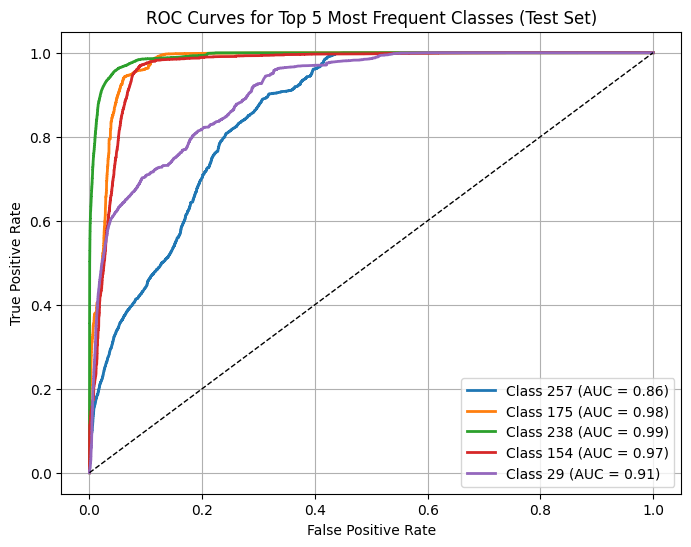

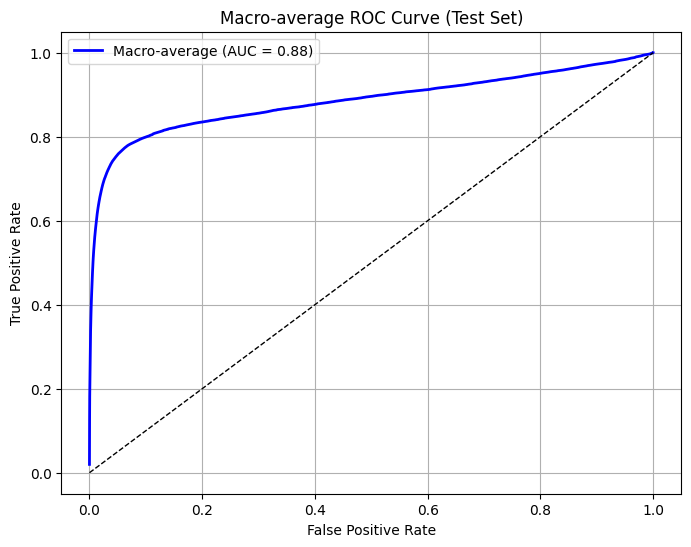

In [73]:
plot_roc_curves(Y_test, Y_pred_proba_list)

In [74]:
def top_k_labels_for_sample(y_pred_proba, k=5, label_names=None):
    """
    Returns the indices (and optionally names) of the top-k predicted labels for a single sample.

    Args:
        y_pred_proba (array-like): 1D array of predicted probabilities for one sample (shape: n_classes).
        k (int): Number of top labels to return.
        label_names (list, optional): List of label names corresponding to each class index.

    Returns:
        top_indices (ndarray): Indices of top-k labels.
        top_scores (ndarray): Their corresponding probabilities.
        top_labels (list, optional): Label names (if provided).
    """
    y_pred_proba = np.array(y_pred_proba)
    top_indices = np.argsort(y_pred_proba)[::-1][:k]
    top_scores = y_pred_proba[top_indices]
    
    if label_names is not None:
        top_labels = [label_names[i] for i in top_indices]
        return top_indices, top_scores, top_labels
    
    return top_indices, top_scores

In [75]:
x = 789
k = 5
actual_labels = true_indices = np.where(Y_test[x] == 1)[0]
print(f"Actual labels are: {actual_labels}")
prop_lis_for_x = Y_pred_proba_list[x]
predicted_labels, predicted_score = top_k_labels_for_sample(prop_lis_for_x, k=5)
print(f"Top {k} predicted labels are:")
for (predicted_label, predicted_score) in zip(predicted_labels, predicted_score) :
    print(f"{predicted_label}: {predicted_score}")

Actual labels are: [ 36  62  66 185 197]
Top 5 predicted labels are:
62: 0.999840119437172
197: 0.033401037426703035
36: 0.026130145688081217
66: 0.01741580126888945
185: 0.0029209694049191115


In [89]:
import numpy as np

# Predict probabilities on TEST set
Y_pred_proba_test = multi_model.predict_proba(X_test_ready)

# Y_pred_proba_test is a list of length n_labels, each element: (n_samples, 2)
# → convert to array of shape (n_labels, n_samples, 2), then keep prob of class 1 and transpose
Y_pred_proba_test_mat = np.array(Y_pred_proba_test)[:, :, 1].T

print("Proba matrix:", Y_pred_proba_test_mat.shape)
print("Y_test:", Y_test.shape)




Proba matrix: (75432, 285)
Y_test: (75432, 285)


In [91]:
# Model 2: ROC AUC
from sklearn.metrics import roc_auc_score

roc_auc_micro = roc_auc_score(Y_test, Y_pred_proba_test_mat, average='micro')
roc_auc_macro = roc_auc_score(Y_test, Y_pred_proba_test_mat, average='macro')

print(f"Test ROC AUC (micro): {roc_auc_micro:.4f}")
print(f"Test ROC AUC (macro): {roc_auc_macro:.4f}")


Test ROC AUC (micro): 0.9155
Test ROC AUC (macro): 0.8846


In [93]:
#Model 3: Top 3 Accuracy Test
top_k = 30
n_samples, n_labels = Y_pred_proba_test_mat.shape

# Indices of top-30 predictions per sample (shape: n_samples × 30)
topk_indices = np.argsort(-Y_pred_proba_test_mat, axis=1)[:, :top_k]

# For each sample, check if ANY of the top-k indices corresponds to a true label = 1
rows = np.arange(n_samples)[:, None]  # shape (n_samples, 1)
hits = (Y_test[rows, topk_indices] == 1).any(axis=1)  # shape (n_samples,)

top30_accuracy = hits.mean()
print(f"Top-{top_k} Accuracy on TEST: {top30_accuracy:.4f}")


Top-30 Accuracy on TEST: 0.9959


In [95]:
#Model 4: False Negative Rate
from sklearn.metrics import confusion_matrix

threshold = 0.5  # change if you’ve tuned a better one

Y_pred_test_bin = (Y_pred_proba_test_mat >= threshold).astype(int)

# Flatten across all samples and labels
y_true_flat = Y_test.ravel()
y_pred_flat = Y_pred_test_bin.ravel()

tn, fp, fn, tp = confusion_matrix(y_true_flat, y_pred_flat).ravel()

fnr_micro = fn / (fn + tp)
print(f"False Negative Rate (micro, threshold={threshold}): {fnr_micro:.4f}")


False Negative Rate (micro, threshold=0.5): 0.9573


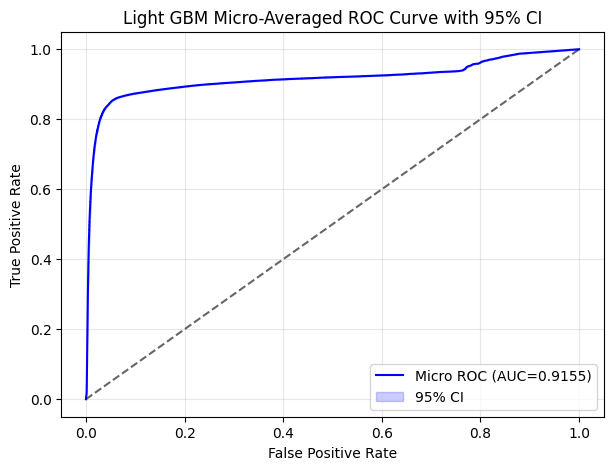

In [104]:
# ============================================================
# 1) MICRO ROC CURVE WITH CONFIDENCE INTERVAL SHADING
# ============================================================

# Flatten prediction + labels
y_true_flat = Y_test.ravel()
y_score_flat = Y_pred_proba_test_mat.ravel()

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_true_flat, y_score_flat)

# Bootstrap confidence bands
boot_fprs = np.linspace(0, 1, 200)
tpr_samples = []

rng = np.random.default_rng(42)

for _ in range(20):  # 200 bootstrap samples
    idx = rng.integers(0, len(y_true_flat), len(y_true_flat))
    y_true_b = y_true_flat[idx]
    y_score_b = y_score_flat[idx]
    fpr_b, tpr_b, _ = roc_curve(y_true_b, y_score_b)
    tpr_interp = np.interp(boot_fprs, fpr_b, tpr_b)
    tpr_samples.append(tpr_interp)

tpr_samples = np.array(tpr_samples)
lower = np.percentile(tpr_samples, 2.5, axis=0)
upper = np.percentile(tpr_samples, 97.5, axis=0)

roc_auc_micro = roc_auc_score(Y_test, Y_pred_proba_test_mat, average='micro')

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"Micro ROC (AUC={roc_auc_micro:.4f})", color="blue")
plt.fill_between(boot_fprs, lower, upper, color="blue", alpha=0.2, label="95% CI")
plt.plot([0,1],[0,1],'k--',alpha=0.6)
plt.title("Light GBM Micro-Averaged ROC Curve with 95% CI")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

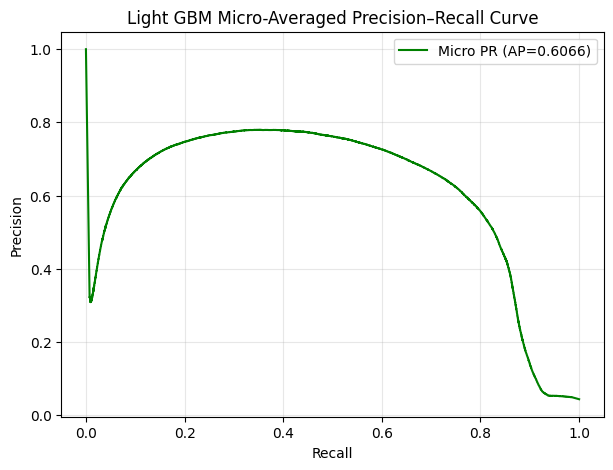

In [105]:
# ============================================================
# 2) MICRO PRECISION–RECALL CURVE (with AP)
# ============================================================
#Why Micro-averged? Each species is highly imbalanced
#Some species appear only a few times
#Others appear many times

precision, recall, _ = precision_recall_curve(y_true_flat, y_score_flat)
ap_micro = average_precision_score(Y_test, Y_pred_proba_test_mat, average='micro')

plt.figure(figsize=(7,5))
plt.plot(recall, precision, color="green", label=f"Micro PR (AP={ap_micro:.4f})")
plt.title("Light GBM Micro-Averaged Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


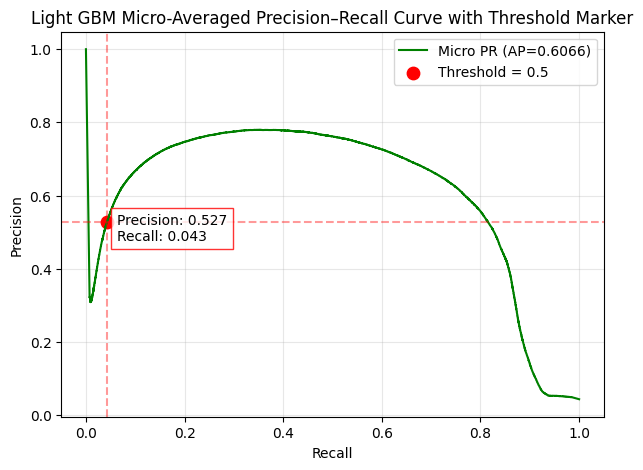

In [107]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Flattened data (already computed earlier)
# y_true_flat = Y_test.ravel()
# y_score_flat = Y_pred_proba_test_mat.ravel()

precision, recall, thresholds = precision_recall_curve(y_true_flat, y_score_flat)
ap_micro = average_precision_score(Y_test, Y_pred_proba_test_mat, average='micro')

# --------------------------
# Select a threshold to highlight
# --------------------------
selected_threshold = 0.5  # feel free to replace with your tuned global threshold

# Find closest threshold index in the list returned by precision_recall_curve
# Note: thresholds has length N-1 while precision & recall have length N
th_idx = np.argmin(np.abs(thresholds - selected_threshold))

# Precision & recall at that threshold
prec_t = precision[th_idx]
rec_t = recall[th_idx]

# --------------------------
# Plot
# --------------------------
plt.figure(figsize=(7, 5))

# PR curve
plt.plot(recall, precision, color="green", label=f"Micro PR (AP={ap_micro:.4f})")

# Highlight chosen threshold point
plt.scatter(rec_t, prec_t, color="red", s=80, label=f"Threshold = {selected_threshold}")
plt.axvline(rec_t, color="red", linestyle="--", alpha=0.4)
plt.axhline(prec_t, color="red", linestyle="--", alpha=0.4)

# Text annotation
plt.text(
    rec_t + 0.02,
    prec_t - 0.05,
    f"Precision: {prec_t:.3f}\nRecall: {rec_t:.3f}",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="red", alpha=0.8)
)

plt.title("Light GBM Micro-Averaged Precision–Recall Curve with Threshold Marker")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


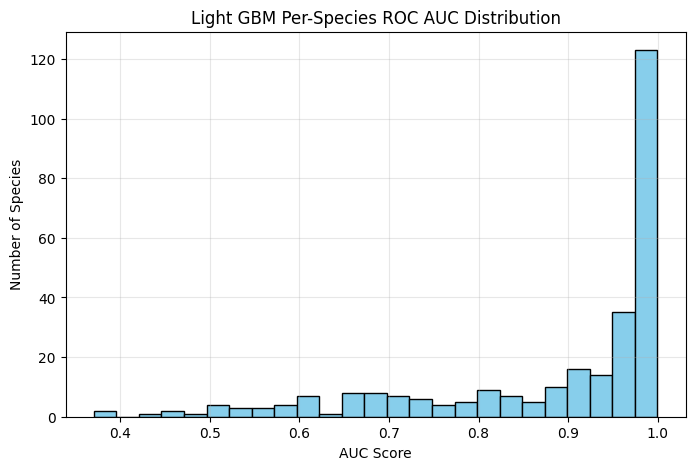

Mean AUC across species: 0.8846
Median AUC across species: 0.9657
Number of species with AUC < 0.6: 21
Number of species with AUC > 0.8: 219


In [106]:
# ============================================================
# 3) PER-SPECIES AUC HISTOGRAM
# ============================================================

per_label_auc = []
for i in range(Y_test.shape[1]):
    # Check if species has positive examples (otherwise AUC is undefined)
    if len(np.unique(Y_test[:, i])) == 2:
        auc = roc_auc_score(Y_test[:, i], Y_pred_proba_test_mat[:, i])
        per_label_auc.append(auc)

plt.figure(figsize=(8,5))
plt.hist(per_label_auc, bins=25, color="skyblue", edgecolor="black")
plt.title("Light GBM Per-Species ROC AUC Distribution")
plt.xlabel("AUC Score")
plt.ylabel("Number of Species")
plt.grid(alpha=0.3)
plt.show()

print(f"Mean AUC across species: {np.mean(per_label_auc):.4f}")
print(f"Median AUC across species: {np.median(per_label_auc):.4f}")
print(f"Number of species with AUC < 0.6: {np.sum(np.array(per_label_auc) < 0.6)}")
print(f"Number of species with AUC > 0.8: {np.sum(np.array(per_label_auc) > 0.8)}")

Since We're doing good (too good for me tbh) Let's do a sanity check

In [109]:
print("Y_test:", Y_test.shape)
print("Y_pred_proba:", Y_pred_proba_test_mat.shape)
print("y_true_flat:", y_true_flat.shape)
print("y_score_flat:", y_score_flat.shape)


Y_test: (75432, 285)
Y_pred_proba: (75432, 285)
y_true_flat: (21498120,)
y_score_flat: (21498120,)


In [111]:
#Sanity Check:
import numpy as np

true_probs = Y_pred_proba_test_mat[Y_test == 1]
false_probs = Y_pred_proba_test_mat[Y_test == 0]

print("Mean predicted prob for TRUE labels: ", np.mean(true_probs))
print("Mean predicted prob for FALSE labels:", np.mean(false_probs))


Mean predicted prob for TRUE labels:  0.0707799151928307
Mean predicted prob for FALSE labels: 0.0019923044621998507


According to Chatgpt, as long as True> False, even if small then the model learned something and t is genuinely ranking positives above negatives.
FALSE labels essentially hover at zero

In [112]:
violations = np.sum(np.diff(precision) > 0)  # count illegal upward jumps
print("Monotonicity violations:", violations)


Monotonicity violations: 3912236


Chatgpt again: It means: your dataset is massive, so the stepwise precision jumps are also massive.

In short:

No issue here. Completely normal. Nothing is broken.

In [113]:
random_scores = np.random.rand(*Y_pred_proba_test_mat.shape)
rand_ap_micro = average_precision_score(Y_test, random_scores, average='micro')
print("Random baseline AP:", rand_ap_micro)
print("Model AP:", ap_micro)


Random baseline AP: 0.04315687692779337
Model AP: 0.6065510775194932


“On average, when a species is truly present, the model gives it a noticeably higher score.
And while overall probabilities are low (because species are rare), the ranking quality is strong. 
The AP of ~0.61 shows the model meaningfully distinguishes positive species occurrences from background noise.”